<a href="https://colab.research.google.com/github/aparnaramchandra2416-gif/wind-turbine-power-prediction/blob/main/Day1_AI_Workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 AI Basics Workshop — Day 1
## AI Foundations, Python Toolkit & Your First Neural Network

---

| | |
|---|---|
| **Audience** | 4th Semester Engineering Students |
| **Prerequisites** | Basic Python (variables, loops, functions) |
| **Platform** | Google Colab (free — no local install needed) |
| **Duration** | ~4 hours of labs across the full day |

---

### 📋 What We Cover Today

| # | Section | Time |
|---|---------|------|
| 1 | Setup & Sanity Check | 10 min |
| 2 | Python for ML: NumPy Basics | 30 min |
| 3 | Python for ML: Pandas & Data Exploration | 45 min |
| 4 | Python for ML: Visualisation with Matplotlib & Seaborn | 30 min |
| 5 | **LAB 1** — Full EDA on the Titanic Dataset | 45 min |
| 6 | Neural Networks: Theory in Code | 30 min |
| 7 | **LAB 2** — First Classifier with Scikit-learn (Iris) | 45 min |
| 8 | Wrap-up & Take-home Challenge | 10 min |

---

> **How to use this notebook:**  
> Run cells **top to bottom** in order. Each `# TODO` marks something for you to complete. Bonus tasks are clearly labelled — attempt them if you finish early.  
> When stuck, raise your hand or check the hint cell below the task.


---
## Section 0 — Setup & Sanity Check
*Run this first. If it prints without errors, you're good to go.*


In [ ]:
# Install / upgrade libraries (run once, ignore the output)
!pip install seaborn scikit-learn matplotlib pandas numpy


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

print("✅  All libraries loaded successfully!")
print(f"   numpy  {np.__version__}")
print(f"   pandas {pd.__version__}")


✅  All libraries loaded successfully!
   numpy  2.0.2
   pandas 2.2.2


---
## Section 1 — NumPy: The Foundation of ML Maths

NumPy gives Python fast, vectorised operations on **arrays** — the data structure that sits underneath every ML framework.

> **Key intuition:** In ML, *everything* is an array. A dataset is a 2D array (rows × features). An image is a 3D array (height × width × channels). A model's parameters are arrays of numbers. NumPy makes working with these fast and clean.


In [7]:
# ── 1.1 Creating Arrays ───────────────────────────────────────────────────────

# From a Python list
a = np.array([1, 2, 3, 4, 5])
print("1D array:", a)
print("Shape:", a.shape, "  dtype:", a.dtype)

# 2D array (like a mini dataset: 3 samples, 2 features)
X = np.array([[1.0, 2.0],
              [3.0, 4.0],
              [5.0, 6.0]])
print("\n2D array (3 rows × 2 cols):\n", X)
print("Shape:", X.shape)
print(type(a))
print(type(X))


1D array: [1 2 3 4 5]
Shape: (5,)   dtype: int64

2D array (3 rows × 2 cols):
 [[1. 2.]
 [3. 4.]
 [5. 6.]]
Shape: (3, 2)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [21]:
# ── 1.2 Useful array creation shortcuts ──────────────────────────────────────

print("np.zeros(5,5)\n→", np.zeros((5,4)))
print("np.ones((3,3))\n", np.ones((3,3)))
print("np.arange(0,10,2) →", np.arange(0, 10, 3))
print("np.linspace(0,1,6) →", np.linspace(0, 1, 6))

# Random arrays — used constantly in ML
np.random.seed(42)
rand_arr = np.random.randn(3, 4)   # standard normal distribution
print("\nRandom 3×4 array:\n", rand_arr.round(3))


np.zeros(5,5)
→ [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
np.ones((3,3))
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
np.arange(0,10,2) → [0 3 6 9]
np.linspace(0,1,6) → [0.  0.2 0.4 0.6 0.8 1. ]

Random 3×4 array:
 [[ 0.497 -0.138  0.648  1.523]
 [-0.234 -0.234  1.579  0.767]
 [-0.469  0.543 -0.463 -0.466]]


In [28]:
# ── 1.3 Vectorised Operations (no loops needed!) ──────────────────────────────

a = np.array([1, 2, 3, 4, 5])
b = np.array([10, 20, 30, 40, 50])
concatination=np.concatenate((a,b))
print(concatination)
print("a + b  =", a + b)
print("a * 2  =", a * 2)
print("a ** 2 =", a ** 2)
print("b / a  =", b / a)

# This is WAY faster than Python loops for large arrays
# (Try it: a + b takes microseconds even for arrays with 1 million elements)


[ 1  2  3  4  5 10 20 30 40 50]
a + b  = [11 22 33 44 55]
a * 2  = [ 2  4  6  8 10]
a ** 2 = [ 1  4  9 16 25]
b / a  = [10. 10. 10. 10. 10.]


In [35]:

# ── 1.4 Indexing & Slicing ────────────────────────────────────────────────────

X = np.array([[10, 20, 30],
              [40, 50, 60],
              [70, 80, 90]])

print("All rows, first column:   ", X[:, 0])
print("First row:                ", X[0, :])
print("Bottom-right 2×2 block:\n", X[2:, 2:])
print("Single element X[1,2]:   ", X[1, 2])


All rows, first column:    [10 40 70]
First row:                 [10 20 30]
Bottom-right 2×2 block:
 [[90]]
Single element X[1,2]:    60


In [37]:
# ── 1.5 Aggregation & Statistics ─────────────────────────────────────────────

data = np.array([4, 7, 2, 9, 1, 5, 8, 3, 6])

print(f"Mean   : {data.mean():.3f}")
print(f"Std Dev: {data.std():.2f}")
print(f"Min    : {data.min()} ,  Max: {data.max()}")
print(f"Sum    : {data.sum()}")
print(f"Median : {np.median(data)}")

# On 2D arrays, use axis argument
M = np.array([[1,2,3],[4,5,6]])
print(f"\nColumn means (axis=0): {M.mean(axis=0)}")
print(f"Row means    (axis=1): {M.mean(axis=1)}")


Mean   : 5.000
Std Dev: 2.58
Min    : 1 ,  Max: 9
Sum    : 45
Median : 5.0

Column means (axis=0): [2.5 3.5 4.5]
Row means    (axis=1): [2. 5.]


### ✏️ Quick Exercise — NumPy

Complete the cell below. If you get stuck, the hint cell follows.


In [38]:
# EXERCISE 1: NumPy
# You are given exam scores for 5 students across 3 subjects.
# Complete each TODO.

scores = np.array([
    [72, 85, 90],   # Student 0
    [88, 76, 95],   # Student 1
    [55, 60, 70],   # Student 2
    [95, 92, 88],   # Student 3
    [65, 70, 75],   # Student 4
])

# TODO 1: Print the shape of the scores array
print("Shape:", scores.shape)          # expected: (5, 3)

# TODO 2: Compute each student's average score (mean across columns)
student_avg = scores.mean(axis=1)
print("Student averages:", student_avg)

# TODO 3: Find the highest score in the entire array
print("Top score:", scores.max())

# TODO 4: Find which student scored highest overall (use np.argmax)
best_student = np.argmax(scores)
print("Best student index:", best_student)

# TODO 5 (bonus): Normalise scores to 0-1 range
# Formula: (score - min) / (max - min)
normalised = (scores - scores.min()) / (scores.max() - scores.min())
print("Normalised scores:\n", normalised)


Shape: (5, 3)
Student averages: [82.33333333 86.33333333 61.66666667 91.66666667 70.        ]
Top score: 95
Best student index: 5
Normalised scores:
 [[0.425 0.75  0.875]
 [0.825 0.525 1.   ]
 [0.    0.125 0.375]
 [1.    0.925 0.825]
 [0.25  0.375 0.5  ]]


### 🔍 Stuck? Practice your prompting skills

Before asking for help, try one of these first:

- **Search:** `numpy array shape attribute python`
- **Search:** `numpy mean along axis 1`
- **Search:** `numpy argmax return index of maximum`
- **Prompt an AI:** *"I have a 2D numpy array of shape (5, 3). How do I compute the mean of each row?"*
- **Prompt an AI:** *"How do I normalise a numpy array to the range 0 to 1?"*

> 💬 **Challenge:** Can you write the prompt that gets you exactly the answer you need — in one shot?


---
## Section 2 — Pandas: Working with Real Data

Pandas gives us the **DataFrame** — a table where rows are observations (samples) and columns are variables (features). It's the standard way to load, clean, and explore datasets before modelling.


In [39]:
# ── 2.1 Creating DataFrames ──────────────────────────────────────────────────

# From a dictionary
df = pd.DataFrame({
    'name'  : ['Alice', 'Bob', 'Charlie', 'Diana'],
    'age'   : [25, 30, 22, 28],
    'score' : [88.5, 72.0, 95.3, 81.7],
    'passed': [True, True, True, True]
})

print(df)
print(f"\nShape: {df.shape}   →  {df.shape[0]} rows, {df.shape[1]} columns")
print("\nColumn dtypes:\n", df.dtypes)


      name  age  score  passed
0    Alice   25   88.5    True
1      Bob   30   72.0    True
2  Charlie   22   95.3    True
3    Diana   28   81.7    True

Shape: (4, 4)   →  4 rows, 4 columns

Column dtypes:
 name       object
age         int64
score     float64
passed       bool
dtype: object


In [40]:
# ── 2.2 Loading a CSV / built-in dataset ─────────────────────────────────────
# We'll use the Titanic dataset — a classic ML benchmark
# It contains info about passengers and whether they survived

titanic = sns.load_dataset('titanic')
print(f"Dataset shape: {titanic.shape}")
print(f"Columns: {list(titanic.columns)}")
titanic.head(8)


Dataset shape: (891, 15)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False


In [41]:
# ── 2.3 Essential Inspection Commands ────────────────────────────────────────
# These are the FIRST commands you run on ANY new dataset

print("=" * 50)
print("dtypes + non-null counts:")
print("=" * 50)
titanic.info()


dtypes + non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [42]:
# Descriptive statistics for numeric columns
titanic.describe().round(2)


,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


In [43]:
# Count missing values per column
missing = titanic.isnull().sum()
missing_pct = (missing / len(titanic) * 100).round(1)
pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct}).sort_values('missing_%', ascending=False)


,missing_count,missing_%
deck,688,77.2
age,177,19.9
embarked,2,0.2
embark_town,2,0.2
sex,0,0.0
pclass,0,0.0
survived,0,0.0
fare,0,0.0
parch,0,0.0
sibsp,0,0.0


In [48]:
# ── 2.4 Selecting Data ───────────────────────────────────────────────────────

# Single column → Series
ages = titanic['age']
print("First 5 ages:", ages.head(10).values)

# Multiple columns → DataFrame
subset = titanic[['survived', 'sex', 'age', 'pclass', 'fare']]
subset.head(10)


First 5 ages: [22. 38. 26. 35. 35. nan 54.  2. 27. 14.]


,survived,sex,age,pclass,fare
0,0,male,22.0,3,7.2500
1,1,female,38.0,1,71.2833
2,1,female,26.0,3,7.9250
3,1,female,35.0,1,53.1000
4,0,male,35.0,3,8.0500
5,0,male,NaN,3,8.4583
6,0,male,54.0,1,51.8625
7,0,male,2.0,3,21.0750
8,1,female,27.0,3,11.1333
9,1,female,14.0,2,30.0708


In [45]:
# ── 2.5 Filtering Rows ───────────────────────────────────────────────────────

# Passengers who survived AND were in 1st class
vip_survivors = titanic[(titanic['survived'] == 1) & (titanic['pclass'] == 1)]
print(f"1st-class survivors: {len(vip_survivors)} people")

# Women under 18
girls = titanic[(titanic['sex'] == 'female') & (titanic['age'] < 18)]
print(f"Female passengers under 18: {len(girls)}")

# Survival rate by gender
print("\nSurvival rate by gender:")
print(titanic.groupby('sex')['survived'].mean().round(3))


1st-class survivors: 136 people
Female passengers under 18: 55

Survival rate by gender:
sex
female    0.742
male      0.189
Name: survived, dtype: float64


In [49]:
# ── 2.6 Handling Missing Values ──────────────────────────────────────────────

df = titanic.copy()

# Strategy 1: Fill with median (for numeric columns)
df['age'] = df['age'].fillna(df['age'].median())
0
# Strategy 2: Fill with most common value (for categorical)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Strategy 3: Drop column if too many missing
df = df.drop(columns=['deck'])   # deck is 77% missing — not useful

print(f"Missing after cleaning: {df.isnull().sum().sum()} total nulls")


Missing after cleaning: 2 total nulls


In [50]:
# ── 2.7 Creating New Features (Feature Engineering) ──────────────────────────

df['family_size']   = df['sibsp'] + df['parch'] + 1   # total people in family
df['is_alone']      = (df['family_size'] == 1).astype(int)
df['fare_per_person'] = df['fare'] / df['family_size']

print("New features added. Sample:")
df[['survived', 'family_size', 'is_alone', 'fare_per_person']].head(6)


New features added. Sample:


,survived,family_size,is_alone,fare_per_person
0,0,2,0,3.62500
1,1,2,0,35.64165
2,1,1,1,7.92500
3,1,2,0,26.55000
4,0,1,1,8.05000
5,0,1,1,8.45830


### ✏️ Quick Exercise — Pandas


In [ ]:
# EXERCISE 2: Pandas Exploration
# Using the titanic DataFrame (already loaded above as `titanic`)

# TODO 1: What is the overall survival rate (fraction of passengers who survived)?
survival_rate = None
print(f"Overall survival rate: {survival_rate:.1%}")

# TODO 2: What is the average fare paid by 1st class vs 3rd class passengers?
avg_fare_by_class = None
print("\nAverage fare by class:")
print(avg_fare_by_class)

# TODO 3: How many passengers embarked from each port? (column: 'embark_town')
port_counts = None
print("\nPassengers per embarkation port:")
print(port_counts)

# TODO 4 (bonus): What is the survival rate broken down by BOTH sex AND pclass?
survival_by_sex_class = None
print("\nSurvival rate by sex and class:")
print(survival_by_sex_class)


### 🔍 Stuck? Practice your prompting skills

- **Search:** `pandas groupby mean single column`
- **Search:** `pandas value_counts series`
- **Search:** `pandas groupby multiple columns aggregate`
- **Prompt an AI:** *"Using pandas, how do I find the mean of column 'survived' grouped by two columns 'sex' and 'pclass'?"*

> 💬 **Challenge:** Try getting the answer with the least number of words in your prompt.


---
## Section 3 — Visualisation with Matplotlib & Seaborn

> **Why visualise?** Statistics can mislead. A correlation coefficient doesn't show you outliers. A mean doesn't show you distribution shape. Always plot your data before modelling.

We'll use:
- **Matplotlib** — the foundation; maximum control
- **Seaborn** — built on Matplotlib; beautiful statistical plots with less code


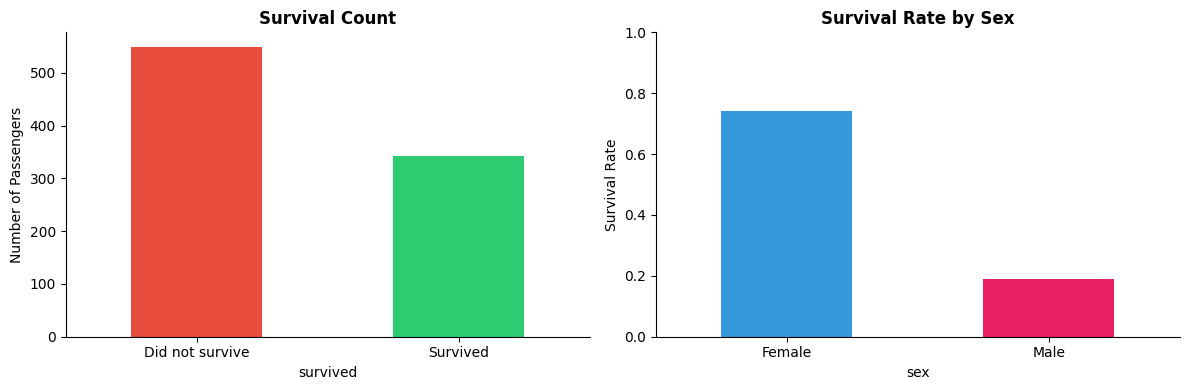

Observation: Women had a much higher survival rate (~74%) vs men (~19%)


In [51]:
# ── 3.1 Bar Chart — Categorical counts ───────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Survival counts
titanic['survived'].value_counts().plot(kind='bar', ax=axes[0],
                                         color=['#E74C3C','#2ECC71'], width=0.5)
axes[0].set_title('Survival Count', fontweight='bold')
axes[0].set_xticklabels(['Did not survive', 'Survived'], rotation=0)
axes[0].set_ylabel('Number of Passengers')

# Right: Survival rate by sex
survival_by_sex = titanic.groupby('sex')['survived'].mean()
survival_by_sex.plot(kind='bar', ax=axes[1], color=['#3498DB','#E91E63'], width=0.5)
axes[1].set_title('Survival Rate by Sex', fontweight='bold')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)
axes[1].set_xticklabels(['Female','Male'], rotation=0)

plt.tight_layout()
plt.show()
print("Observation: Women had a much higher survival rate (~74%) vs men (~19%)")


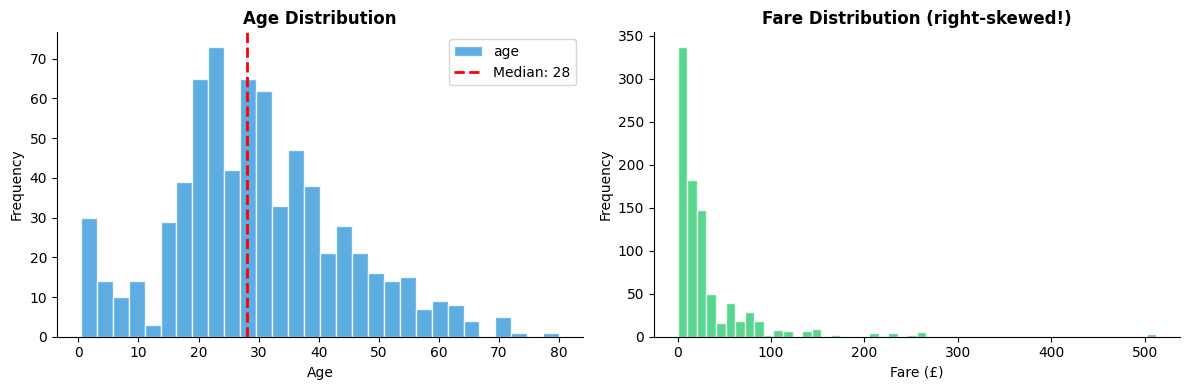

In [52]:
# ── 3.2 Histogram — Distribution of a numeric variable ───────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
titanic['age'].dropna().plot(kind='hist', bins=30, ax=axes[0],
                              color='#3498DB', edgecolor='white', alpha=0.8)
axes[0].axvline(titanic['age'].median(), color='red', linestyle='--', linewidth=2, label=f"Median: {titanic['age'].median():.0f}")
axes[0].set_title('Age Distribution', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].legend()

# Fare distribution (log scale — fare is very right-skewed)
titanic['fare'].plot(kind='hist', bins=50, ax=axes[1],
                     color='#2ECC71', edgecolor='white', alpha=0.8)
axes[1].set_title('Fare Distribution (right-skewed!)', fontweight='bold')
axes[1].set_xlabel('Fare (£)')

plt.tight_layout()
plt.show()


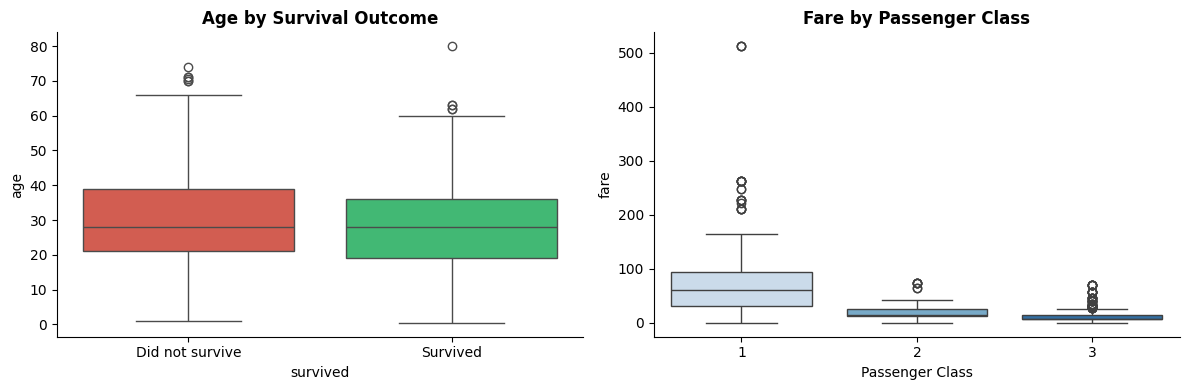

In [53]:
# ── 3.3 Boxplot — Distribution by category ───────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age by survival
sns.boxplot(data=titanic, x='survived', y='age', ax=axes[0],
            palette=['#E74C3C','#2ECC71'])
axes[0].set_xticklabels(['Did not survive', 'Survived'])
axes[0].set_title('Age by Survival Outcome', fontweight='bold')

# Fare by passenger class
sns.boxplot(data=titanic, x='pclass', y='fare', ax=axes[1],
            palette='Blues')
axes[1].set_title('Fare by Passenger Class', fontweight='bold')
axes[1].set_xlabel('Passenger Class')

plt.tight_layout()
plt.show()


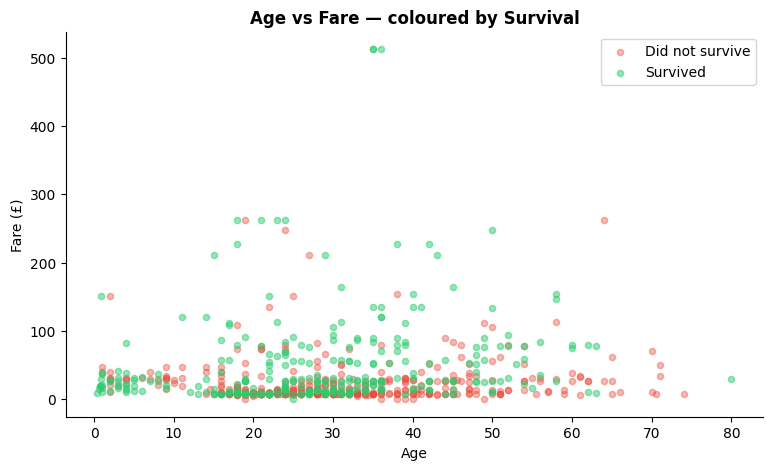

In [54]:
# ── 3.4 Scatter Plot — Relationship between two numeric variables ─────────────

plt.figure(figsize=(9, 5))
survived   = titanic[titanic['survived'] == 1]
not_survived = titanic[titanic['survived'] == 0]

plt.scatter(not_survived['age'], not_survived['fare'],
            alpha=0.4, color='#E74C3C', label='Did not survive', s=20)
plt.scatter(survived['age'], survived['fare'],
            alpha=0.5, color='#2ECC71', label='Survived', s=20)

plt.xlabel('Age')
plt.ylabel('Fare (£)')
plt.title('Age vs Fare — coloured by Survival', fontweight='bold')
plt.legend()
plt.show()


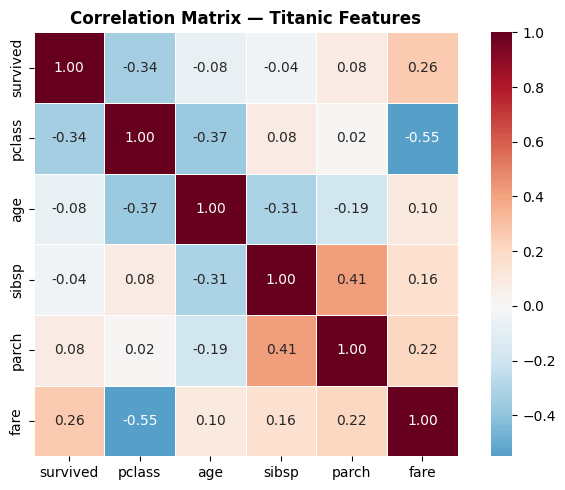

Key insight: 'pclass' and 'survived' are negatively correlated (-0.34)
→ Lower class number = higher survival (1st class fared best)


In [55]:
# ── 3.5 Heatmap — Correlation Matrix ─────────────────────────────────────────

numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr = titanic[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — Titanic Features', fontweight='bold')
plt.tight_layout()
plt.show()

print("Key insight: 'pclass' and 'survived' are negatively correlated (-0.34)")
print("→ Lower class number = higher survival (1st class fared best)")


---
## 🧪 LAB 1 — Full Exploratory Data Analysis on Titanic

**Goal:** Produce a mini EDA report on the Titanic dataset. Each task builds a chart or insight that tells part of the story.  
**Time:** ~45 minutes  
**Deliverable:** All 6 tasks completed with plots and written observations.

---


In [56]:
# LAB 1 SETUP — Run this first
titanic = sns.load_dataset('titanic')
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic = titanic.drop(columns=['deck'])

print(f"Dataset loaded: {titanic.shape[0]} passengers, {titanic.shape[1]} features")
titanic.head(3)


Dataset loaded: 891 passengers, 14 features


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True


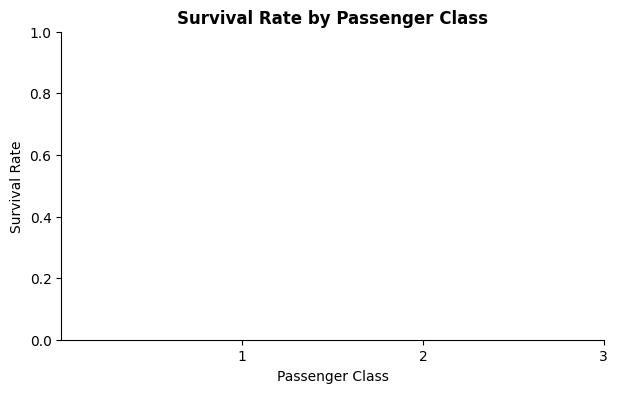


Observation: 


In [58]:
# ── TASK 1: Survival rate by passenger class ─────────────────────────────────
# Create a bar chart showing survival rate for each passenger class (1, 2, 3)
# Add data labels (the percentage) on top of each bar.

# TODO: Compute survival rate by pclass
survival_by_class = None

# TODO: Plot a bar chart
fig, ax = plt.subplots(figsize=(7, 4))
# your plotting code here




ax.set_title('Survival Rate by Passenger Class', fontweight='bold')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Survival Rate')
ax.set_xticks([1, 2, 3])
plt.show()

# TODO: Write one observation
print("\nObservation: ")


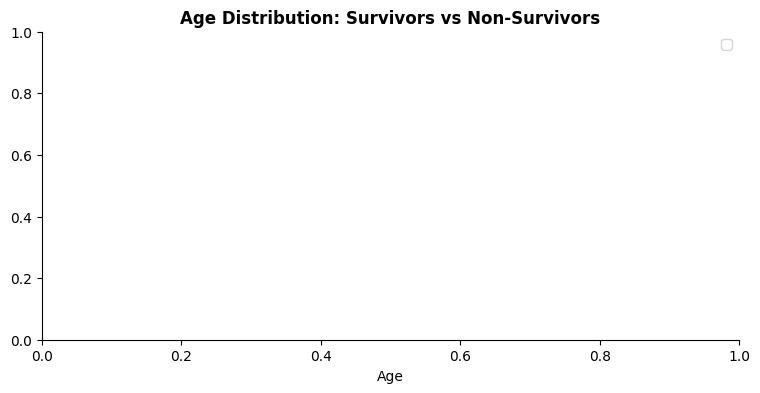

Observation: 


In [59]:
# ── TASK 2: Age distribution — survivors vs non-survivors ────────────────────
# Plot two overlapping histograms of age, one for each survival outcome.
# Use alpha=0.6 so both are visible.

fig, ax = plt.subplots(figsize=(9, 4))

# TODO: Plot histogram for non-survivors (survived==0)

# TODO: Plot histogram for survivors (survived==1)

ax.set_title('Age Distribution: Survivors vs Non-Survivors', fontweight='bold')
ax.set_xlabel('Age')
ax.legend(['Did not survive', 'Survived'])
plt.show()

# TODO: Write one observation
print("Observation: ")


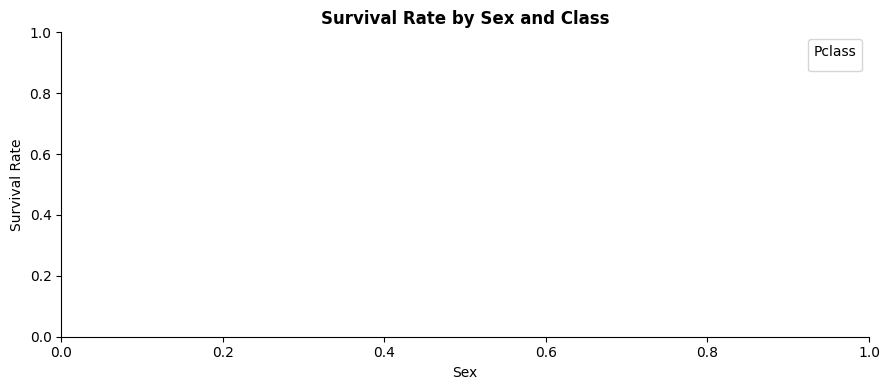

Observation: 


In [60]:
# ── TASK 3: Survival rate by sex AND class (grouped bar chart) ───────────────
# Use a grouped bar chart or seaborn's catplot / barplot

fig, ax = plt.subplots(figsize=(9, 4))

# TODO: Compute survival rate grouped by sex and pclass
pivot = None

# TODO: Plot it
# pivot.plot(kind='bar', ax=ax, ...)

ax.set_title('Survival Rate by Sex and Class', fontweight='bold')
ax.set_xlabel('Sex')
ax.set_ylabel('Survival Rate')
plt.legend(title='Pclass', labels=['1st','2nd','3rd'])
plt.tight_layout()
plt.show()

print("Observation: ")


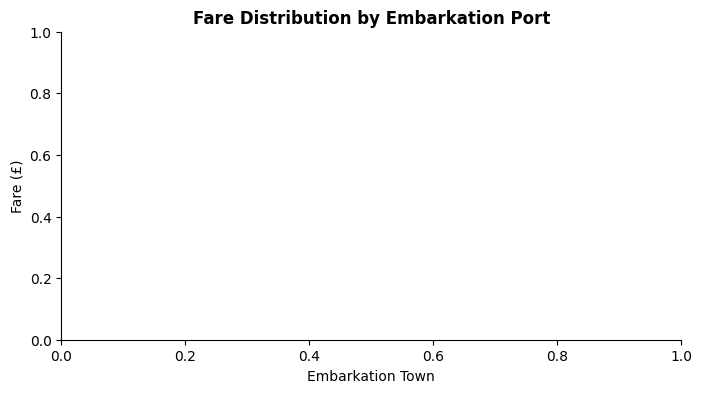

Observation: 


In [61]:
# ── TASK 4: Fare distribution by embarkation port ────────────────────────────
# Use a boxplot to show fare spread across the 3 embarkation towns.
# Use seaborn's boxplot or violinplot.

fig, ax = plt.subplots(figsize=(8, 4))

# TODO: Create a boxplot of 'fare' by 'embark_town'

ax.set_title('Fare Distribution by Embarkation Port', fontweight='bold')
ax.set_xlabel('Embarkation Town')
ax.set_ylabel('Fare (£)')
plt.show()

print("Observation: ")


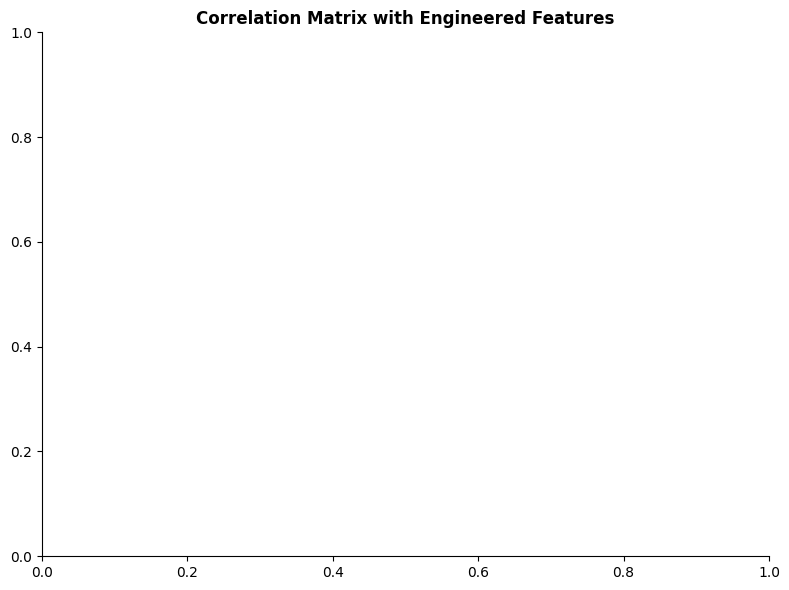

Strongest predictor of survival (excluding survival itself): 


In [62]:
# ── TASK 5: Correlation heatmap with engineered features ─────────────────────
# First add the engineered features from Section 2.7, then plot correlation.

titanic['family_size']    = titanic['sibsp'] + titanic['parch'] + 1
titanic['is_alone']       = (titanic['family_size'] == 1).astype(int)
titanic['fare_per_person']= titanic['fare'] / titanic['family_size']

# TODO: Select these columns and compute correlation
# ['survived', 'pclass', 'age', 'fare', 'family_size', 'is_alone', 'fare_per_person']
cols = ['survived', 'pclass', 'age', 'fare', 'family_size', 'is_alone', 'fare_per_person']
corr = None

# TODO: Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))

plt.title('Correlation Matrix with Engineered Features', fontweight='bold')
plt.tight_layout()
plt.show()

print("Strongest predictor of survival (excluding survival itself): ")


In [63]:
# ── TASK 6 (Bonus): Your own chart ───────────────────────────────────────────
# Come up with one insight that the above charts don't already show.
# Ideas:
#   - Survival rate by number of siblings/spouses aboard
#   - Age distribution by passenger class
#   - A count of passengers per embarkation town, coloured by survival

# Your chart here:



### 🔍 Stuck on Lab 1? Practice your prompting skills

Try these before asking:

| Task | What to search / prompt |
|------|------------------------|
| Task 1 | `pandas groupby bar chart with data labels matplotlib` |
| Task 2 | `matplotlib overlapping histograms two groups alpha` |
| Task 3 | `pandas groupby two columns unstack bar chart` |
| Task 4 | `seaborn boxplot categorical x axis` |
| Task 5 | `seaborn heatmap annotated correlation matrix` |

> 💬 **Prompting challenge:** Describe your exact chart in plain English to an AI tool and see if it writes working code. Then figure out *why* the code works — don't just paste and run.


---
## Section 4 — Neural Networks: Theory in Code

Before we build a classifier, let's see the key ideas play out in simple Python/NumPy code. No ML library needed here.

> **The big picture:**  
> 1. A neuron computes a **weighted sum** of its inputs, then passes it through an **activation function**  
> 2. A network is many neurons stacked in **layers**  
> 3. Training = adjusting weights to **minimise a loss function** via **gradient descent**


In [65]:
# ── 4.1 A Single Neuron ──────────────────────────────────────────────────────

def sigmoid(z):
    """Maps any value to (0, 1) — used for binary output"""
    return 1 / (1 + np.exp(-z))

def relu(z):
    """Returns z if positive, else 0 — the most common activation"""
    return np.maximum(0, z)

# A neuron with 3 inputs
inputs  = np.array([0.5, -1.2, 0.8])   # x: input features
weights = np.array([0.4,  0.3, -0.6])  # w: learned parameters
bias    = 0.1                           # b: learned offset

# Forward pass
z = np.dot(inputs, weights) + bias     # linear combination
output_sigmoid = sigmoid(z)
output_relu    = relu(z)

print(f"Linear output (z)     : {z:.4f}")
print(f"After sigmoid          : {output_sigmoid:.4f}  (interpreted as probability)")
print(f"After ReLU             : {output_relu:.4f}  (used in hidden layers)")


Linear output (z)     : -0.5400
After sigmoid          : 0.3682  (interpreted as probability)
After ReLU             : 0.0000  (used in hidden layers)


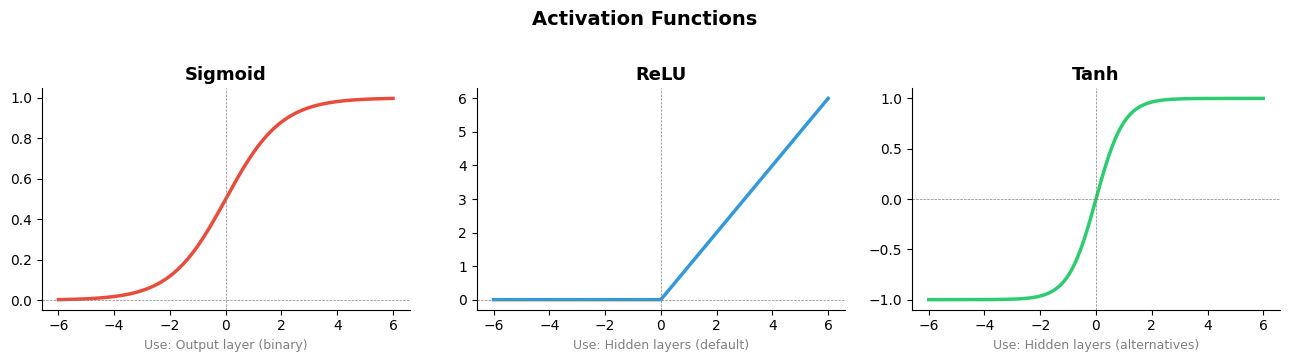

In [66]:
# ── 4.2 Visualising Activation Functions ─────────────────────────────────────

z_values = np.linspace(-6, 6, 200)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

activations = [
    ('Sigmoid',  lambda z: 1/(1+np.exp(-z)),  '#E74C3C', 'Output layer (binary)'),
    ('ReLU',     lambda z: np.maximum(0, z),  '#3498DB', 'Hidden layers (default)'),
    ('Tanh',     np.tanh,                      '#2ECC71', 'Hidden layers (alternatives)'),
]

for ax, (name, fn, color, use_case) in zip(axes, activations):
    ax.plot(z_values, fn(z_values), color=color, linewidth=2.5)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_title(f'{name}', fontweight='bold', fontsize=13)
    ax.set_xlabel(f'Use: {use_case}', fontsize=9, color='gray')

plt.suptitle('Activation Functions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [73]:
# ── 4.3 What is a Loss Function? ─────────────────────────────────────────────
# The loss tells us: "how wrong is our prediction?"
# Training = minimising the loss by adjusting weights

def mse_loss(y_true, y_pred):
    """Mean Squared Error — used for regression"""
    return np.mean((y_true - y_pred) ** 2)

# Suppose true labels are [1, 0, 1, 1, 0]
y_true = np.array([1, 0, 1, 1, 0])

# Model A: bad predictions
pred_bad  = np.array([0.1, 0.9, 0.2, 0.3, 0.8])
# Model B: good predictions
pred_good = np.array([0.9, 0.1, 0.8, 0.9, 0.1])

print(f"Bad  model loss: {mse_loss(y_true, pred_bad):.4f}")
print(f"Good model loss: {mse_loss(y_true, pred_good):.4f}")
print("\nLower loss = better model ✓")


Bad  model loss: 0.6780
Good model loss: 0.0160

Lower loss = better model ✓


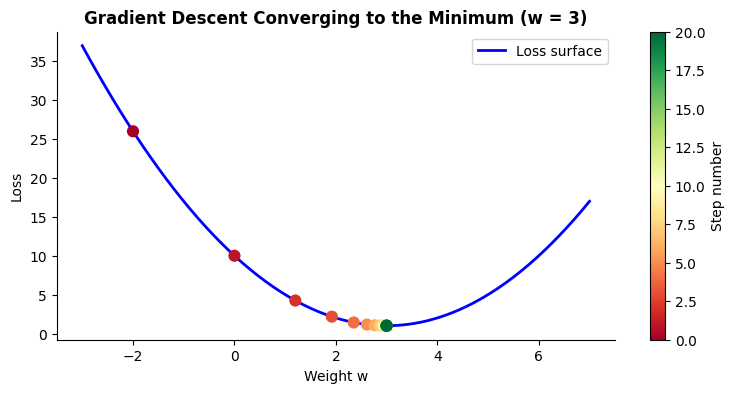

Final weight: 2.9998  (true minimum is 3.0)
Converged in 20 steps


In [74]:
# ── 4.4 Gradient Descent — The Learning Algorithm ────────────────────────────
# We adjust each weight by a small step in the direction that reduces the loss.
# The step size is called the LEARNING RATE.

# Simple 1D illustration
def loss_fn(w):
    """A made-up loss surface — parabola centred at w=3"""
    return (w - 3) ** 2 + 1

w = -2.0          # start far from the minimum
lr = 0.2          # learning rate
history = [w]

for step in range(20):
    gradient = 2 * (w - 3)    # derivative of (w-3)^2 + 1
    w = w - lr * gradient     # gradient descent update
    history.append(w)

# Plot the loss surface and the optimisation path
w_vals = np.linspace(-3, 7, 200)
plt.figure(figsize=(9, 4))
plt.plot(w_vals, loss_fn(w_vals), 'b-', linewidth=2, label='Loss surface')
plt.scatter(history, [loss_fn(h) for h in history],
            c=range(len(history)), cmap='RdYlGn', s=60, zorder=5)
plt.colorbar(label='Step number')
plt.xlabel('Weight w')
plt.ylabel('Loss')
plt.title('Gradient Descent Converging to the Minimum (w = 3)', fontweight='bold')
plt.legend()
plt.show()

print(f"Final weight: {w:.4f}  (true minimum is 3.0)")
print(f"Converged in {len(history)-1} steps")


---
## 🧪 LAB 2 — Your First Neural Network Classifier

**Goal:** Use Scikit-learn's `MLPClassifier` to classify Iris flowers into 3 species.  
You'll go through the complete ML workflow: load → explore → preprocess → train → evaluate.

**Time:** ~45 minutes  
**Dataset:** [Iris](https://scikit-learn.org/stable/datasets/toy_dataset.html#iris-dataset) — 150 samples, 4 features, 3 classes

---


In [78]:
# ── STEP 1: Load and Explore the Dataset ─────────────────────────────────────
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data           # shape: (150, 4)
y = iris.target         # shape: (150,)  — 0, 1, or 2
feature_names   = iris.feature_names
target_names    = iris.target_names

print("Features:", feature_names)
print("Classes :", target_names)
print("X shape :", X.shape)
print("y shape :", y.shape, "  Unique classes:", np.unique(y))

# Convert to DataFrame for easy inspection
iris_df = pd.DataFrame(X, columns=feature_names)
iris_df['species'] = [target_names[i] for i in y]
iris_df.head(6)


Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes : ['setosa' 'versicolor' 'virginica']
X shape : (150, 4)
y shape : (150,)   Unique classes: [0 1 2]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa


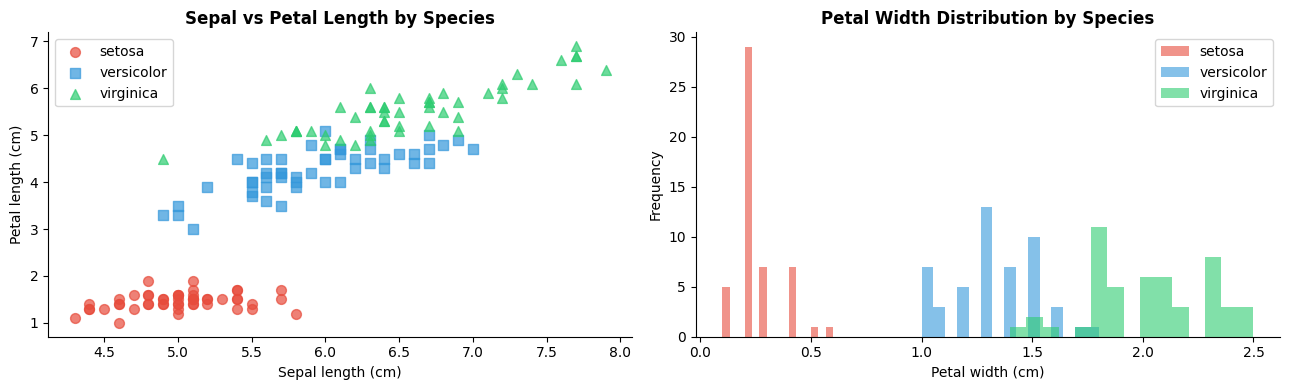


Observation: Setosa is clearly separable. Versicolor and Virginica overlap slightly.


In [76]:
# ── STEP 2: Visualise the Data ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#E74C3C', '#3498DB', '#2ECC71']
markers = ['o', 's', '^']

# Scatter: sepal length vs petal length
for i, (species, color, marker) in enumerate(zip(target_names, colors, markers)):
    mask = y == i
    axes[0].scatter(X[mask, 0], X[mask, 2], c=color, marker=marker,
                    label=species, alpha=0.7, s=50)
axes[0].set_xlabel('Sepal length (cm)')
axes[0].set_ylabel('Petal length (cm)')
axes[0].set_title('Sepal vs Petal Length by Species', fontweight='bold')
axes[0].legend()

# Distribution of petal width by species
for i, (species, color) in enumerate(zip(target_names, colors)):
    iris_df[iris_df['species']==species]['petal width (cm)'].plot(
        kind='hist', bins=15, alpha=0.6, color=color, label=species, ax=axes[1])
axes[1].set_title('Petal Width Distribution by Species', fontweight='bold')
axes[1].set_xlabel('Petal width (cm)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nObservation: Setosa is clearly separable. Versicolor and Virginica overlap slightly.")


In [77]:
# ── STEP 3: Split Data — Train / Test ────────────────────────────────────────

# TODO: Use train_test_split with test_size=0.2 and random_state=42
X_train, X_test, y_train, y_test = None, None, None, None

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Class balance (train): {np.bincount(y_train)}")


TypeError: object of type 'NoneType' has no len()

### 🔍 Stuck? Practice your prompting skills

- **Search:** `sklearn train_test_split stratify parameter`
- **Prompt an AI:** *"How do I split a dataset into training and test sets in scikit-learn while preserving class proportions?"*

> 💬 **Think first:** Why do we need `stratify=y`? What happens to class balance if we don't use it on a small dataset?


In [ ]:
# ── STEP 4: Normalise Features ────────────────────────────────────────────────
# Neural networks are sensitive to feature scale.
# StandardScaler transforms each feature to mean=0, std=1.

# TODO: Create a StandardScaler, fit on X_train, transform BOTH X_train and X_test
scaler = StandardScaler()
X_train_scaled = None
X_test_scaled  = None

print("Before scaling — mean of first feature:", X_train[:, 0].mean().round(3))
print("After  scaling — mean of first feature:", X_train_scaled[:, 0].mean().round(6))
print("After  scaling — std  of first feature:", X_train_scaled[:, 0].std().round(6))


### 🔍 Stuck? Practice your prompting skills

- **Search:** `sklearn StandardScaler fit_transform vs transform difference`
- **Prompt an AI:** *"Why should I never call fit_transform on my test set when using StandardScaler?"*

> 💬 **Concept check:** This is one of the most common data leakage mistakes in ML. Make sure you can explain *why* in your own words before moving on.


In [ ]:
# ── STEP 5: Build and Train the Neural Network ───────────────────────────────

# TODO: Create an MLPClassifier with the following settings:
#   - hidden_layer_sizes=(64, 32)   — two hidden layers, 64 and 32 neurons
#   - activation='relu'
#   - max_iter=500
#   - random_state=42
#   Then fit it on the scaled training data.

model = None     # create the MLPClassifier here

# fit here

print("✅  Model trained!")
print(f"   Architecture: input(4) → 64 → 32 → output(3)")
print(f"   Iterations used: {model.n_iter_}")


In [ ]:
# ── STEP 6: Evaluate the Model ───────────────────────────────────────────────

# TODO: Predict on X_test_scaled and compute accuracy
y_pred = None
acc = None

print(f"Test Accuracy: {acc:.2%}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


In [ ]:
# ── STEP 7: Confusion Matrix ─────────────────────────────────────────────────
# The confusion matrix shows WHICH classes are being confused.
# Diagonal = correct predictions. Off-diagonal = mistakes.

# TODO: Plot the confusion matrix using ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(6, 5))

plt.title('Confusion Matrix — Iris Classifier', fontweight='bold')
plt.tight_layout()
plt.show()

# TODO: Fill in the blanks
print(f"The model confused __________ with __________ the most.")
print(f"It perfectly classified all __________ samples.")


### 🔍 Stuck? Practice your prompting skills

- **Search:** `sklearn ConfusionMatrixDisplay from_predictions example`
- **Search:** `sklearn classification_report output explained`
- **Prompt an AI:** *"What is the difference between precision and recall? Give me an example using a medical diagnosis scenario."*

> 💬 **Challenge:** After you get the confusion matrix working, try to explain each cell to the person sitting next to you without looking at the notebook.


In [ ]:
# ── STEP 8: Experiment — Change the Architecture ─────────────────────────────
# Run this cell multiple times with different architectures and fill in the table.

architectures = [
    (32,),
    (64, 32),
    (128, 64, 32),
    (16,),
]

results = []
for arch in architectures:
    m = MLPClassifier(hidden_layer_sizes=arch, max_iter=500, random_state=42)
    m.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, m.predict(X_test_scaled))
    results.append({'Architecture': str(arch), 'Test Accuracy': f'{acc:.2%}', 'Iterations': m.n_iter_})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print("\nObservation: ")


In [ ]:
# ── STEP 9 (Bonus): Learning Curve — Does adding training data help? ───────────
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42),
    X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training accuracy', color='#3498DB')
plt.plot(train_sizes, val_scores.mean(axis=1),   'o-', label='Validation accuracy', color='#E74C3C')
plt.fill_between(train_sizes, val_scores.mean(axis=1)-val_scores.std(axis=1),
                               val_scores.mean(axis=1)+val_scores.std(axis=1), alpha=0.1, color='#E74C3C')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning Curve — Does More Data Help?', fontweight='bold')
plt.legend()
plt.show()

print("Interpretation: if validation accuracy is still rising at the right end, more data would help.")


---
## ✅ Day 1 Wrap-up

### What you built today

| | |
|---|---|
| 📊 **NumPy** | Fast array operations — the engine under every ML framework |
| 🐼 **Pandas** | Load, clean, filter, and engineer features from real data |
| 📈 **Matplotlib / Seaborn** | Reveal patterns visually before any modelling |
| 🤖 **Scikit-learn MLPClassifier** | Full ML pipeline: split → scale → train → evaluate |

### Key takeaways

1. **Data exploration always comes first.** Visualise before you model.
2. **Always split before scaling.** Fit the scaler on train only.
3. **Accuracy alone isn't enough.** Use precision, recall, and the confusion matrix.
4. **Architecture matters, but not as much as data quality.**

---

## 🏠 Take-home Challenge

Pick any dataset from [Kaggle](https://www.kaggle.com/datasets) or [UCI ML Repository](https://archive.ics.uci.edu/datasets).

**Deliverable:** A Colab notebook with:
1. At least 5 exploratory charts with one-line observations
2. A trained `MLPClassifier` (or `MLPRegressor` for regression tasks)
3. Accuracy or RMSE reported on a held-out test set
4. One sentence: *"The most surprising thing I found in this data was..."*

Share your notebook link at the start of **Day 2**.

---

## 📚 Resources

| Resource | What for |
|---|---|
| [Kaggle Learn — Pandas](https://www.kaggle.com/learn/pandas) | Short free micro-course on Pandas |
| [Numpy Quickstart](https://numpy.org/doc/stable/user/quickstart.html) | Official numpy tutorial |
| [Scikit-learn User Guide](https://scikit-learn.org/stable/user_guide.html) | Every algorithm explained |
| [TensorFlow Playground](https://playground.tensorflow.org) | Visualise neural networks interactively |
| [3Blue1Brown — Neural Networks series](https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi) | Best visual explanation of backprop |
